# Sprint 2 Analysis Notebook

c:\Users\rishi\n100-financial-intelligence\database\n100.db
True
  company_id      year  sales  net_profit    eps  total_assets  \
0        ABB  Dec 2012   1653         145   68.0         907.0   
1        ABB  Mar 2014   2276         198   93.0        1139.0   
2        ABB  Mar 2014   2276         198   93.0        1139.0   
3        ABB  Mar 2015   2289         229  108.0        1374.0   
4        ABB  Mar 2015   2289         229  108.0        1374.0   

   equity_capital  reserves  borrowings  operating_activity  \
0            21.0     626.0         0.0               101.0   
1            21.0     767.0         0.0               155.0   
2            21.0     767.0         0.0                 0.0   
3            21.0     916.0         0.0               215.0   
4            21.0     916.0         0.0               -35.0   

   investing_activity  financing_activity  
0               -59.0               -42.0  
1              -144.0               -42.0  
2                 0.0      

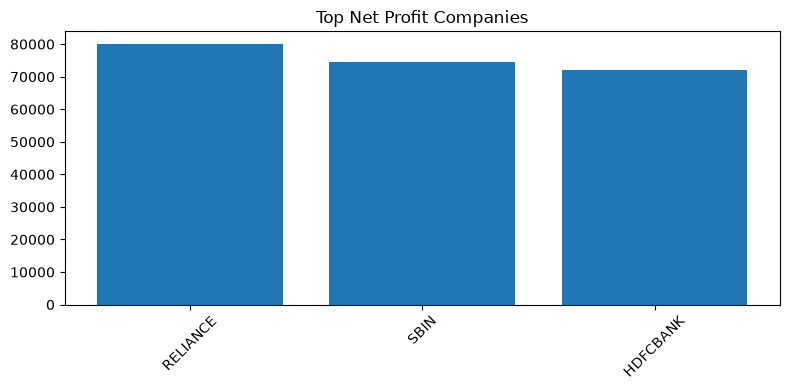

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
DB_PATH = PROJECT_ROOT / "database" / "n100.db"
REPORTS_DIR = PROJECT_ROOT / "reports"

print("Database path:", DB_PATH)
print("Database exists:", DB_PATH.exists())

conn = sqlite3.connect(DB_PATH)
profit_df = pd.read_sql("SELECT company_id, year, sales, net_profit, eps FROM profitandloss", conn)
balance_df = pd.read_sql("SELECT company_id, year, total_assets, equity_capital, reserves, borrowings FROM balancesheet", conn)
cashflow_df = pd.read_sql("SELECT company_id, year, operating_activity, investing_activity, financing_activity FROM cashflow", conn)
conn.close()

merged = profit_df.merge(balance_df, on=["company_id", "year"], how="left").merge(cashflow_df, on=["company_id", "year"], how="left")
merged = merged.dropna(subset=["sales", "net_profit"])

print("Merged rows:", len(merged))

for metric_name, metric_value in [("Top ROE", "net_profit"), ("Top Revenue", "sales")]:
    ranking = merged.sort_values(metric_value, ascending=False).head(8)
    print(metric_name)
    print(ranking[["company_id", "year", metric_value]].to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(merged["company_id"].head(8).astype(str), merged["net_profit"].head(8))
plt.title("Top Net Profit Companies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [2]:
from pathlib import Path

print(Path.cwd())

c:\Users\rishi\n100-financial-intelligence\notebooks
